| Campo | Detalle |
|---|---|
| **Autor** | [Borja Mora Méndez](https://www.linkedin.com/in/borja-mora-mendez/) |
| **Contacto** | borja.mora.mendez@gmail.com |
| **Categoría** | Python > Análisis Exploratorio (EDA) |
| **Técnica principal** | pandas groupby, seaborn/matplotlib, creación de métricas derivadas |
| **Dataset** | `tips` (seaborn) — 244 tickets de un restaurante |
| **Última actualización** | julio 2026 |


# Análisis de clientes y propinas en un restaurante

Una cadena de restaurantes nos contrata para estudiar patrones de consumo y propinas, con el objetivo de **optimizar los ingresos** y **mejorar la experiencia del cliente**.

## Preguntas de negocio que vamos a responder

1. ¿Qué factores influyen en los **ingresos**?
2. ¿Qué tipo de cliente deja **más propina**?
3. ¿Cuándo conviene **asignar más personal**?
4. ¿Cómo aumentar la **rentabilidad**?

## Plan de trabajo

1. Cargar librerías y dataset.
2. Exploración inicial (`head`, `info`, `describe`).
3. Una variable nueva muy útil: **`tip_pct`** = `tip / total_bill * 100` (% de propina).
4. Responder cada pregunta con tablas + gráficos sencillos.
5. Conclusiones de negocio.

## 1. Cargar librerías

In [1]:
# CARGAR LIBRERÍAS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo de los gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Cargar el dataset

Usamos `sns.load_dataset('tips')`. Es el mismo dataset que el del Excel, pero limpio (Excel a veces convierte por error decimales como `1.01` en fechas).

In [2]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# ¿Cuántas filas y columnas tenemos? ¿Hay nulos?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Resumen estadístico de las columnas numéricas
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


**Lectura rápida:**
- 244 tickets, sin nulos. Bien.
- Ticket medio: ~19,8 €. Propina media: ~3 €. Mesa media: ~2,5 personas.

## 3. Crear la variable más importante: `tip_pct` (% de propina)

La propina en euros depende del tamaño del ticket. Para comparar entre clientes lo justo es ver **qué porcentaje del ticket dejan como propina**.

In [5]:
df['tip_pct'] = df['tip'] / df['total_bill'] * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


## Pregunta 1: ¿Qué factores influyen en los ingresos?

El ingreso es `total_bill`. Vamos a comparar cómo cambia según cada variable.

In [6]:
# Ticket medio por día y franja horaria
print('--- Ticket medio por día ---')
print(df.groupby('day', observed=True)['total_bill'].mean().round(2))

print('\n--- Ticket medio por franja (Lunch/Dinner) ---')
print(df.groupby('time', observed=True)['total_bill'].mean().round(2))

print('\n--- Ticket medio por tamaño de mesa ---')
print(df.groupby('size', observed=True)['total_bill'].mean().round(2))

--- Ticket medio por día ---
day
Thur    17.68
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64

--- Ticket medio por franja (Lunch/Dinner) ---
time
Lunch     17.17
Dinner    20.80
Name: total_bill, dtype: float64

--- Ticket medio por tamaño de mesa ---
size
1     7.24
2    16.45
3    23.28
4    28.61
5    30.07
6    34.83
Name: total_bill, dtype: float64


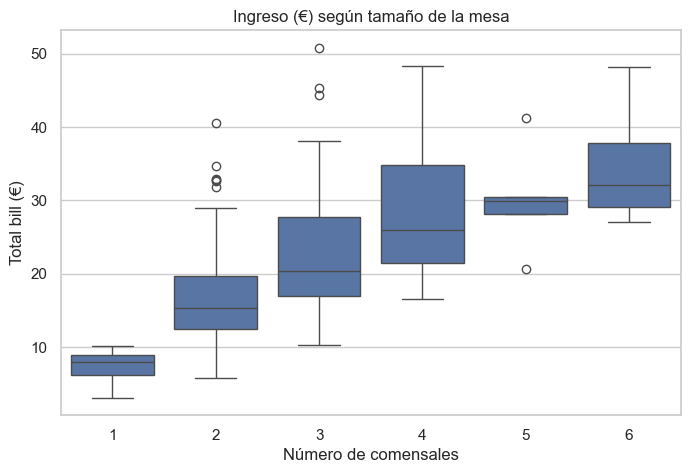

In [7]:
# Gráfico: total_bill vs size (tamaño de mesa)
sns.boxplot(data=df, x='size', y='total_bill')
plt.title('Ingreso (€) según tamaño de la mesa')
plt.xlabel('Número de comensales')
plt.ylabel('Total bill (€)')
plt.show()

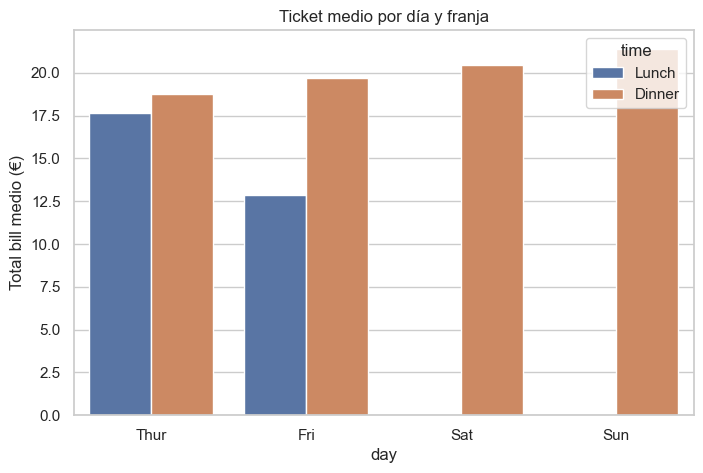

In [8]:
# Gráfico: total_bill por día, separando Lunch y Dinner
sns.barplot(data=df, x='day', y='total_bill', hue='time', errorbar=None)
plt.title('Ticket medio por día y franja')
plt.ylabel('Total bill medio (€)')
plt.show()

**Conclusión P1:**
- **El tamaño de la mesa es el factor que más sube el ingreso** (lógico: más comensales, más comida).
- **La cena factura más que la comida.**
- El día con mayor ticket medio es el **domingo**.

## Pregunta 2: ¿Qué tipo de cliente deja más propina?

Comparamos `tip_pct` (% de propina, no euros) por cada variable categórica.

In [9]:
print('--- % propina medio por sexo ---')
print(df.groupby('sex', observed=True)['tip_pct'].mean().round(2))

print('\n--- % propina medio por fumador ---')
print(df.groupby('smoker', observed=True)['tip_pct'].mean().round(2))

print('\n--- % propina medio por día ---')
print(df.groupby('day', observed=True)['tip_pct'].mean().round(2))

print('\n--- % propina medio por tamaño de mesa ---')
print(df.groupby('size', observed=True)['tip_pct'].mean().round(2))

--- % propina medio por sexo ---
sex
Male      15.77
Female    16.65
Name: tip_pct, dtype: float64

--- % propina medio por fumador ---
smoker
Yes    16.32
No     15.93
Name: tip_pct, dtype: float64

--- % propina medio por día ---
day
Thur    16.13
Fri     16.99
Sat     15.32
Sun     16.69
Name: tip_pct, dtype: float64

--- % propina medio por tamaño de mesa ---
size
1    21.73
2    16.57
3    15.22
4    14.59
5    14.15
6    15.62
Name: tip_pct, dtype: float64


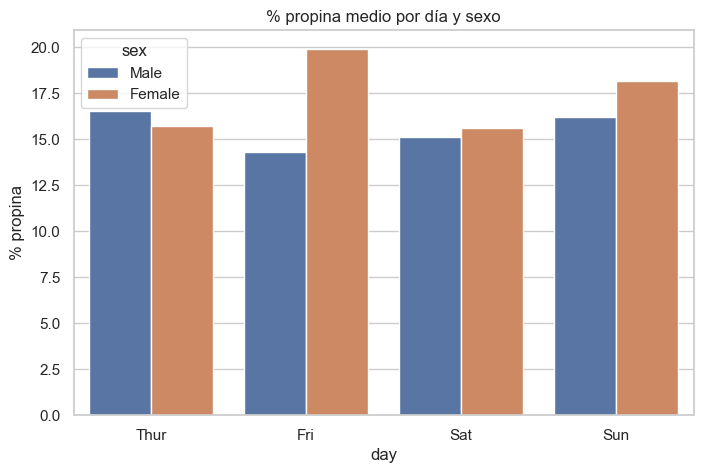

In [10]:
# Gráfico: % propina por día y sexo
sns.barplot(data=df, x='day', y='tip_pct', hue='sex', errorbar=None)
plt.title('% propina medio por día y sexo')
plt.ylabel('% propina')
plt.show()

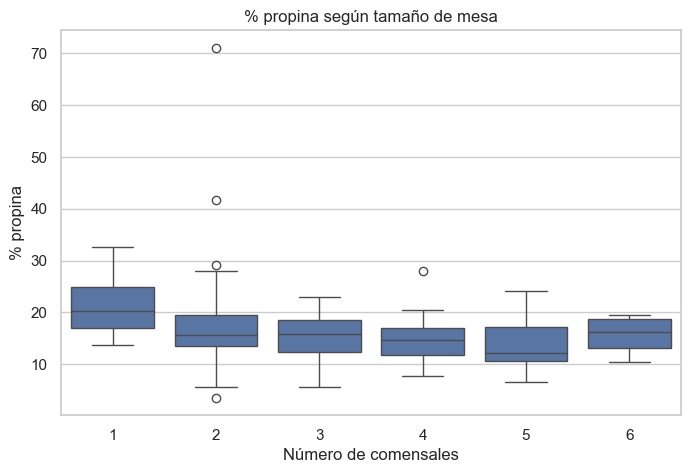

In [11]:
# Gráfico: % propina según tamaño de mesa
sns.boxplot(data=df, x='size', y='tip_pct')
plt.title('% propina según tamaño de mesa')
plt.ylabel('% propina')
plt.xlabel('Número de comensales')
plt.show()

**Conclusión P2:**
- **Las mesas pequeñas (1-2 personas) dejan mayor % de propina.** Las mesas grandes propinan menos en proporción.
- Hombres y mujeres dejan **% similar** (no es un factor relevante).
- Fumadores y no fumadores propinan **muy parecido en %** (la diferencia es pequeña).

## Pregunta 3: ¿Cuándo conviene asignar más personal?

Aquí lo que importa es **el volumen de tickets** (cuántas mesas atendemos), no el ticket medio. Si hay muchas mesas → necesitamos más camareros.

In [12]:
# Número de tickets por día y franja
tickets = df.groupby(['day', 'time'], observed=True).size().unstack(fill_value=0)
tickets

time,Lunch,Dinner
day,,
Thur,61,1
Fri,7,12
Sat,0,87
Sun,0,76


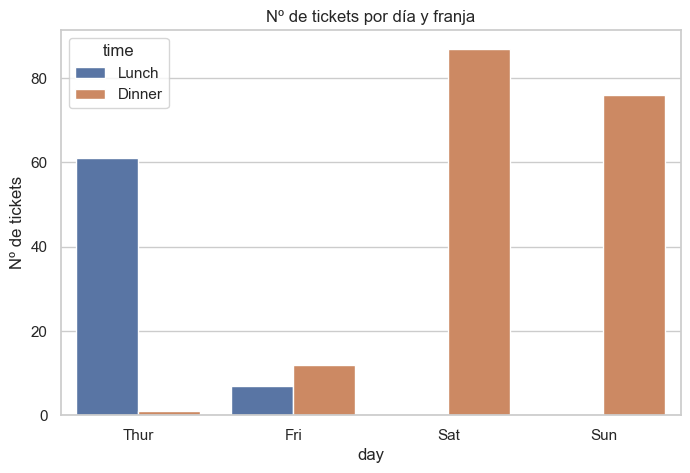

In [13]:
# Gráfico: nº de tickets por día y franja
sns.countplot(data=df, x='day', hue='time')
plt.title('Nº de tickets por día y franja')
plt.ylabel('Nº de tickets')
plt.show()

In [14]:
# Ingresos totales (€) por día -> aquí sí queremos facturación total
ingresos = df.groupby('day', observed=True)['total_bill'].sum().round(2).sort_values(ascending=False)
print('Ingresos totales por día (€):')
print(ingresos)

Ingresos totales por día (€):
day
Sat     1778.40
Sun     1627.16
Thur    1096.33
Fri      325.88
Name: total_bill, dtype: float64


**Conclusión P3:**
- **El sábado es el día con más tickets** y más facturación, seguido del domingo.
- La **cena** concentra la mayor parte del volumen.
- **Refuerzo de personal: viernes noche, sábado todo el día y domingo a la hora de la cena.** Los jueves se puede operar con plantilla mínima.

## Pregunta 4: ¿Cómo aumentar la rentabilidad?

Síntesis: combinamos lo aprendido en las tres preguntas anteriores.

In [15]:
# Mapa resumen: ticket medio + propina media + nº tickets por día/franja
resumen = df.groupby(['day', 'time'], observed=True).agg(
 n_tickets=('total_bill', 'count'),
 ticket_medio=('total_bill', 'mean'),
 propina_media_pct=('tip_pct', 'mean'),
 facturacion_total=('total_bill', 'sum')
).round(2).sort_values('facturacion_total', ascending=False)
resumen

n_tickets  ticket_medio  propina_media_pct  facturacion_total
day  time                                                                 
Sat  Dinner         87         20.44              15.32            1778.40
Sun  Dinner         76         21.41              16.69            1627.16
Thur Lunch          61         17.66              16.13            1077.55
Fri  Dinner         12         19.66              15.89             235.96
     Lunch           7         12.85              18.88              89.92
Thur Dinner          1         18.78              15.97              18.78

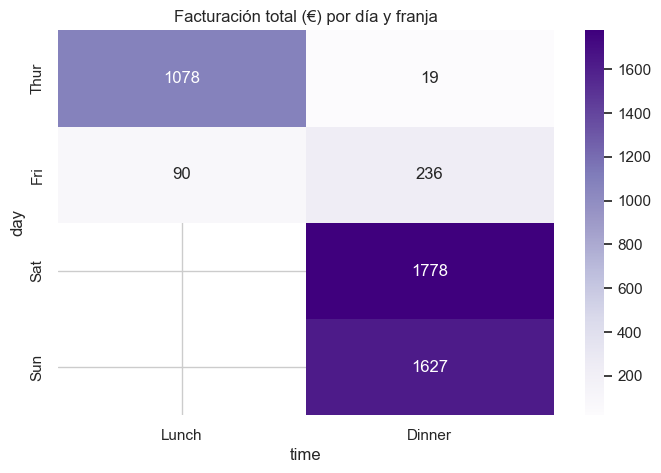

In [16]:
# Heatmap: facturación total por día y franja (visual rápido para la dirección)
pivot = df.pivot_table(index='day', columns='time', values='total_bill', aggfunc='sum', observed=True)
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Purples')
plt.title('Facturación total (€) por día y franja')
plt.show()

## Conclusiones finales de negocio

| # | Pregunta | Respuesta corta |
|---|---|---|
| 1 | ¿Qué factores influyen en los ingresos? | El **tamaño de la mesa** y la **cena** son los grandes motores del ticket. |
| 2 | ¿Qué cliente deja más propina (%)? | Las **mesas pequeñas (1-2 personas)**. Sexo y fumador apenas importan. |
| 3 | ¿Cuándo asignar más personal? | **Viernes noche, sábado completo y domingo cena.** Jueves: plantilla mínima. |
| 4 | ¿Cómo aumentar la rentabilidad? | Tres palancas claras (ver recomendaciones debajo) |

### Tres recomendaciones accionables

1. **Atraer grupos grandes a la cena del fin de semana** (promos para mesas de 4+), porque suben mucho la facturación.
2. **Cuidar la experiencia de las mesas pequeñas**, porque son las que mejor propinan en proporción → forman al personal y suben el ticket medio (entrante o postre sugerido).
3. **Optimizar la plantilla**: reforzar viernes-sábado-domingo en la cena y aligerar jueves y comidas de diario. Reduce coste de personal sin perder ventas.